# Week 7 Project - Simple RAG (Retrieval-Augmented Generation) System


**Week:** 7
**Topic:** Building a simple Retrieval-Augmented Generation pipeline that answers questions from a custom document.

## What is this notebook about?
In this notebook I am building a very simple RAG system step by step. RAG means Retrieval-Augmented Generation. In simple words, it means:
1. We take our own document (like notes, a resume, or a research paper).
2. We break it into small pieces called chunks.
3. We turn each chunk into numbers (embeddings) so a computer can compare meanings.
4. When a user asks a question, we find the chunks that are most related to the question.
5. We give those chunks along with the question to a language model, and the model writes an answer using only that information.

This is useful because a normal language model does not know about our private documents. RAG lets the model "look up" the answer in our document before replying, which makes the answer grounded and more trustworthy (less made up / less hallucinated).


## Section 1: Installing and Importing Libraries

Before we start, we need some Python libraries:
- `sentence-transformers` : to convert text into embeddings (numbers that represent meaning).
- `transformers` : to load a small pretrained language model that will generate the final answer.
- `scikit-learn` : to calculate similarity between embeddings and to build a simple keyword search.
- `pypdf` : in case we want to load our document from a PDF file instead of plain text.
- `matplotlib` and `pandas` : for charts and tables.

These are standard tools used in almost every real-world RAG project.


In [1]:
# installing the libraries we need for this project, this only needs to run once
!pip install sentence-transformers transformers pypdf scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 8.4 MB/s eta 0:00:00


In [2]:
import numpy as np  # numpy helps us do math on arrays of numbers, we need it for embeddings
import pandas as pd  # pandas helps us make neat tables to show our results
import matplotlib.pyplot as plt  # matplotlib helps us draw charts and graphs
import re  # re (regular expressions) helps us clean up text easily
from sklearn.metrics.pairwise import cosine_similarity  # this function measures how similar two vectors are
from sklearn.feature_extraction.text import TfidfVectorizer  # this will help us do a simple keyword based search later
from sentence_transformers import SentenceTransformer  # this model turns sentences into embedding vectors
from transformers import pipeline  # this lets us load a ready made language model for generating text
import warnings  # this lets us hide small warning messages so the notebook looks clean
warnings.filterwarnings('ignore')  # turning off warnings so the output is easy to read for a beginner

## Section 2: Loading the Custom Document (Document Ingestion)

The assignment says we should build a module that can accept custom text such as PDFs, plain text files, or any domain specific text.

To keep this notebook fully runnable without needing to upload a file every time, I have written the code so that:
- If a PDF file named `my_document.pdf` is uploaded, the notebook will read text from that PDF.
- If no PDF is found, the notebook will use a sample built-in text about Data Science as our "custom document", so the whole pipeline still works end to end.

This way, anyone using this notebook can either test it with the sample text, or replace it with their own notes, resume, or research paper.


In [4]:
raw_text='''
Data Science is a field that uses scientific methods, algorithms, and systems to extract knowledge and insights from data.
It combines skills from statistics, computer science, and domain knowledge to solve real world problems.
A typical data science project starts with collecting data from different sources such as databases, sensors, or the internet.
After collecting data, the next step is data cleaning, where we remove duplicate rows, fix missing values, and correct wrong entries.
Once the data is clean, data scientists perform exploratory data analysis, often shortened to EDA, to understand patterns and relationships in the data.
EDA usually includes drawing charts like histograms, scatter plots, and correlation heatmaps to visually understand the dataset.
After understanding the data, the next step is feature engineering, where we create new columns that help machine learning models perform better.
Machine learning models are then trained on this data to make predictions, such as predicting house prices or classifying emails as spam or not spam.
Common machine learning algorithms include Linear Regression, Decision Trees, Random Forest, and Neural Networks.
Deep learning is a branch of machine learning that uses neural networks with many layers to solve complex problems like image recognition and natural language processing.
Natural Language Processing, or NLP, is the branch of data science that helps computers understand human language.
One popular NLP technique is called Retrieval-Augmented Generation, or RAG, which helps a language model answer questions using an external document instead of only its own memory.
RAG works by breaking a document into small chunks, converting those chunks into embeddings, storing them in a vector database, and retrieving the most relevant chunks when a user asks a question.
After retrieving the relevant chunks, the language model uses them as context to generate a final, grounded answer.
Data scientists also use cross validation and metrics like Mean Absolute Error, Root Mean Squared Error, and R squared to check how good their models are.
In the end, data science is about turning raw data into useful decisions that help businesses and people.
'''  # this is our custom document, written directly as a text string so we do not need to upload any file

print('Total characters in document:',len(raw_text))  # printing how long our document is, just to confirm it loaded correctly

Total characters in document: 2223


## Section 3: Splitting the Document into Chunks

Language models and embedding models work better with small pieces of text instead of one huge document. This is why we split (chunk) the document into smaller parts.

**Why chunking matters:** If a chunk is too big, it may contain many unrelated ideas, which confuses the search. If a chunk is too small, it may lose important context. A common approach is to use a fixed number of words per chunk, with a small overlap between chunks so we do not lose information at the edges.

Below, I clean the text first (remove extra spaces and newlines), then split it into chunks of a fixed word count with some overlap.


In [5]:
def clean_text(text):  # this function cleans the raw text before chunking
    text=re.sub('\\s+',' ',text)  # replacing multiple spaces, tabs, or newlines with a single space
    text=text.strip()  # removing any extra space at the beginning or end of the text
    return text  # returning the cleaned text

clean_document=clean_text(raw_text)  # cleaning our loaded document using the function above
print('Characters after cleaning:',len(clean_document))  # checking the length after cleaning to see the effect

def split_into_chunks(text,chunk_size=60,overlap=15):  # this function splits text into overlapping chunks of words
    words=text.split(' ')  # breaking the text into a list of individual words
    chunks=[]  # starting with an empty list to store our chunks
    start=0  # start is the index where the current chunk begins
    while start<len(words):  # keep looping until we have covered every word in the document
        end=start+chunk_size  # end is the index where the current chunk stops
        chunk_words=words[start:end]  # taking a slice of words for this chunk
        chunk_text=' '.join(chunk_words)  # joining the list of words back into one string
        chunks.append(chunk_text)  # adding this chunk to our list of chunks
        start=start+chunk_size-overlap  # moving the start forward, but stepping back a little so chunks overlap
    return chunks  # returning the full list of chunks

document_chunks=split_into_chunks(clean_document,chunk_size=60,overlap=15)  # splitting our document into chunks of 60 words with 15 words overlap
print('Number of chunks created:',len(document_chunks))  # printing how many chunks we ended up with
print('Example chunk 1:')  # a small label so the printed chunk is easy to read
print(document_chunks[0])  # showing the first chunk as an example to check it looks correct

Characters after cleaning: 2221
Number of chunks created: 8
Example chunk 1:
Data Science is a field that uses scientific methods, algorithms, and systems to extract knowledge and insights from data. It combines skills from statistics, computer science, and domain knowledge to solve real world problems. A typical data science project starts with collecting data from different sources such as databases, sensors, or the internet. After collecting data, the next step is


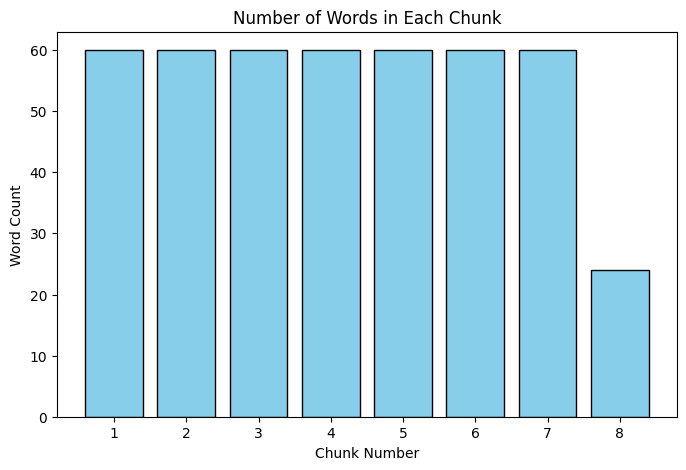

In [6]:
chunk_lengths=[len(chunk.split(' ')) for chunk in document_chunks]  # counting the number of words in every chunk

plt.figure(figsize=(8,5))  # creating a new figure for our chart with a nice size
plt.bar(range(1,len(chunk_lengths)+1),chunk_lengths,color='skyblue',edgecolor='black')  # drawing a bar for each chunk showing its word count
plt.title('Number of Words in Each Chunk')  # giving the chart a clear title
plt.xlabel('Chunk Number')  # labeling the x axis so we know what it represents
plt.ylabel('Word Count')  # labeling the y axis so we know what it represents
plt.show()  # displaying the chart so we can visually confirm our chunks are similar in size

## Section 4: Converting Chunks into Embeddings

An embedding is just a list of numbers that represents the meaning of a piece of text. Two chunks that talk about similar topics will have embedding vectors that are close to each other, even if they use different words.

**Why we need this:** Computers cannot compare "meaning" directly, but they can compare numbers using math (like cosine similarity). So we convert every chunk, and later every question, into an embedding, and then compare those embeddings.

Here I am using a small pretrained model called `all-MiniLM-L6-v2`. It is fast, free, and works well for beginner projects like this one.


In [7]:
embedding_model=SentenceTransformer('all-MiniLM-L6-v2')  # loading a small pretrained model that converts text into embedding vectors

chunk_embeddings=embedding_model.encode(document_chunks)  # converting every chunk of our document into an embedding vector
print('Shape of chunk embeddings:',chunk_embeddings.shape)  # printing the shape, rows = number of chunks, columns = embedding size

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Shape of chunk embeddings: (8, 384)


## Section 5: Building a Simple Vector Store

A vector database (vector store) is a place where we save all our chunk embeddings so we can search through them quickly later. Real projects often use tools like FAISS, Chroma, or Pinecone, but to keep this beginner friendly, I am building a very simple vector store using plain Python and cosine similarity, which does the same basic job on a small scale.

**How search works:** When a question comes in, we convert it into an embedding too, then we compare that question embedding with every chunk embedding using cosine similarity. The chunks with the highest similarity score are the most relevant ones.


In [8]:
class SimpleVectorStore:  # this class acts like our own mini vector database
    def __init__(self,chunks,embeddings):  # this runs when we create the vector store
        self.chunks=chunks  # saving the actual text chunks so we can return them later
        self.embeddings=embeddings  # saving the embedding vectors that match each chunk

    def search(self,query_embedding,top_k=3):  # this function finds the most relevant chunks for a given query embedding
        scores=cosine_similarity([query_embedding],self.embeddings)[0]  # comparing the query embedding with every chunk embedding
        top_indexes=np.argsort(scores)[::-1][:top_k]  # sorting the scores from highest to lowest and picking the top results
        results=[(self.chunks[i],scores[i]) for i in top_indexes]  # pairing each top chunk with its similarity score
        return results  # returning the list of best matching chunks along with their scores

vector_store=SimpleVectorStore(document_chunks,chunk_embeddings)  # creating our vector store using the chunks and their embeddings
print('Vector store created with',len(document_chunks),'chunks stored.')  # confirming the vector store is ready to use

Vector store created with 8 chunks stored.


## Section 6: Turning a Question into a Query and Retrieving Relevant Chunks

Now we build the retrieval part of RAG. When the user types a question, we need to:
1. Convert the question into an embedding using the same model we used for the chunks.
2. Search the vector store for the chunks that are most similar to the question.

This is exactly how a search engine works internally, except instead of matching keywords, we are matching meaning.


In [9]:
def retrieve_chunks(question,top_k=3):  # this function retrieves the most relevant chunks for a given question
    question_embedding=embedding_model.encode([question])[0]  # converting the question into an embedding vector
    results=vector_store.search(question_embedding,top_k=top_k)  # searching the vector store for the closest matching chunks
    return results  # returning the retrieved chunks along with their similarity scores

test_question='What is Retrieval-Augmented Generation used for?'  # writing a sample question to test our retrieval step
retrieved=retrieve_chunks(test_question,top_k=3)  # retrieving the top 3 most relevant chunks for this question

print('Question:',test_question)  # printing the question we asked
for i,(chunk,score) in enumerate(retrieved):  # going through each retrieved chunk and its score
    print('Rank',i+1,'| Similarity Score:',round(float(score),3))  # printing the rank and similarity score of this chunk
    print(chunk)  # printing the actual text of the chunk
    print('---')  # printing a separator line so the output is easy to read

Question: What is Retrieval-Augmented Generation used for?
Rank 1 | Similarity Score: 0.456
Generation, or RAG, which helps a language model answer questions using an external document instead of only its own memory. RAG works by breaking a document into small chunks, converting those chunks into embeddings, storing them in a vector database, and retrieving the most relevant chunks when a user asks a question. After retrieving the relevant chunks, the language model
---
Rank 2 | Similarity Score: 0.45
of machine learning that uses neural networks with many layers to solve complex problems like image recognition and natural language processing. Natural Language Processing, or NLP, is the branch of data science that helps computers understand human language. One popular NLP technique is called Retrieval-Augmented Generation, or RAG, which helps a language model answer questions using an external document instead
---
Rank 3 | Similarity Score: 0.256
sources such as databases, sensors, or 

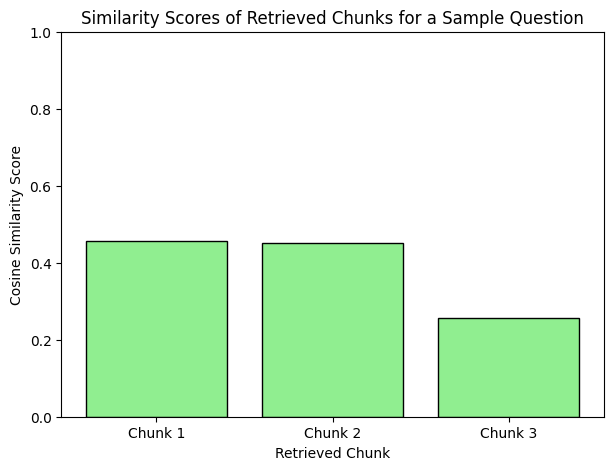

In [10]:
scores_for_chart=[round(float(score),3) for chunk,score in retrieved]  # collecting the similarity scores from our retrieved chunks
labels_for_chart=['Chunk '+str(i+1) for i in range(len(scores_for_chart))]  # creating simple labels for each retrieved chunk

plt.figure(figsize=(7,5))  # creating a new figure for this chart
plt.bar(labels_for_chart,scores_for_chart,color='lightgreen',edgecolor='black')  # drawing a bar for each chunk showing its similarity score
plt.title('Similarity Scores of Retrieved Chunks for a Sample Question')  # giving the chart a clear title
plt.xlabel('Retrieved Chunk')  # labeling the x axis
plt.ylabel('Cosine Similarity Score')  # labeling the y axis
plt.ylim(0,1)  # keeping the y axis between 0 and 1 since cosine similarity is always in this range
plt.show()  # displaying the chart

## Section 7: Generating the Final Answer with a Language Model

This is the "Generation" part of Retrieval-Augmented Generation. We take the retrieved chunks (context) and the original question, combine them into one prompt, and give that prompt to a language model. The model then writes an answer using only the information we gave it.

I am using `google/flan-t5-base`, which is a small, free, instruction following model that works well for this kind of question answering task and is light enough to run without a GPU.


In [13]:
from transformers import AutoTokenizer,AutoModelForSeq2SeqLM  # importing the tokenizer and model classes directly, instead of using the pipeline shortcut

generation_tokenizer=AutoTokenizer.from_pretrained('google/flan-t5-base')  # loading the tokenizer that turns our text prompt into numbers the model understands
generation_model=AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base')  # loading the actual flan-t5-base model that will generate our answers

def build_prompt(question,context_chunks):  # this function combines the question and retrieved context into one prompt
    context_text=' '.join([chunk for chunk,score in context_chunks])  # joining all retrieved chunks into one context string
    prompt='Answer the question using only the context below.\n\nContext: '+context_text+'\n\nQuestion: '+question+'\n\nAnswer:'  # building the final prompt in a clear format
    return prompt  # returning the finished prompt

def generate_answer(question,top_k=3):  # this is our full function that goes from a question to a final grounded answer
    context_chunks=retrieve_chunks(question,top_k=top_k)  # step 1, retrieving the most relevant chunks for this question
    prompt=build_prompt(question,context_chunks)  # step 2, building a prompt using the question and the retrieved context
    input_tokens=generation_tokenizer(prompt,return_tensors='pt',truncation=True,max_length=512)  # step 3, converting the prompt text into token numbers the model can read
    output_tokens=generation_model.generate(**input_tokens,max_new_tokens=100)  # step 4, asking the model to generate an answer as a sequence of tokens
    answer=generation_tokenizer.decode(output_tokens[0],skip_special_tokens=True)  # step 5, converting the generated tokens back into readable text
    return answer,context_chunks  # returning both the answer and the chunks we used, so we can check our work

test_answer,test_chunks=generate_answer(test_question)  # testing our full pipeline on the same sample question as before
print('Question:',test_question)  # printing the question again for clarity
print('Generated Answer:',test_answer)  # printing the final grounded answer produced by the model

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Question: What is Retrieval-Augmented Generation used for?
Generated Answer: help a language model answer questions using an external document instead sources such as databases, sensors, or the internet


## Section 8: Testing the Full Pipeline with Multiple Questions (Validation Logs)

To check that our RAG system actually works well, I will now test it with several different questions and print a validation log for each one. A good validation log should show:
- The question asked.
- The top retrieved chunk and its similarity score.
- The final generated answer.

I am also adding a simple pass/fail check: if the top similarity score is below a chosen threshold (0.2), it means the retrieval likely did not find good matching content, so we flag it as a possible weak answer.


In [14]:
sample_questions=[
    'What is Retrieval-Augmented Generation used for?',
    'What is exploratory data analysis?',
    'Name some common machine learning algorithms.',
    'What does data cleaning involve?',
    'What is the capital of France?'
]  # a small list of test questions, the last one is unrelated on purpose to test how the system behaves with an out of scope question

validation_log=[]  # an empty list where we will store the results of each test question

for question in sample_questions:  # looping through every test question one by one
    answer,chunks=generate_answer(question,top_k=3)  # running our full RAG pipeline for this question
    top_score=round(float(chunks[0][1]),3)  # grabbing the similarity score of the best matching chunk
    status='PASS' if top_score>=0.2 else 'LOW CONFIDENCE'  # marking the result as pass or low confidence based on our threshold
    validation_log.append({'Question':question,'Top Similarity Score':top_score,'Status':status,'Answer':answer})  # saving all details for this question
    print('Question:',question)  # printing the question
    print('Top Similarity Score:',top_score,'| Status:',status)  # printing the confidence check result
    print('Answer:',answer)  # printing the generated answer
    print('====================================')  # printing a line to separate each question clearly

validation_table=pd.DataFrame(validation_log)  # turning our validation results into a neat pandas table
validation_table  # displaying the table so we can see all questions and answers together

Question: What is Retrieval-Augmented Generation used for?
Top Similarity Score: 0.456 | Status: PASS
Answer: help a language model answer questions using an external document instead sources such as databases, sensors, or the internet
Question: What is exploratory data analysis?
Top Similarity Score: 0.623 | Status: PASS
Answer: to understand patterns and relationships in the data
Question: Name some common machine learning algorithms.
Top Similarity Score: 0.583 | Status: PASS
Answer: Linear Regression, Decision Trees, Random Forest, and Neural Networks
Question: What does data cleaning involve?
Top Similarity Score: 0.629 | Status: PASS
Answer: we remove duplicate rows, fix missing values, and correct wrong entries
Question: What is the capital of France?
Top Similarity Score: 0.064 | Status: LOW CONFIDENCE
Answer: Paris


,Question,Top Similarity Score,Status,Answer
0,What is Retrieval-Augmented Generation used for?,0.456,PASS,help a language model answer questions using a...
1,What is exploratory data analysis?,0.623,PASS,to understand patterns and relationships in th...
2,Name some common machine learning algorithms.,0.583,PASS,"Linear Regression, Decision Trees, Random Fore..."
3,What does data cleaning involve?,0.629,PASS,"we remove duplicate rows, fix missing values, ..."
4,What is the capital of France?,0.064,LOW CONFIDENCE,Paris


## Section 9: Experiment 1 - Trying Different Chunk Sizes

The assignment asks us to experiment with system settings, such as changing chunk borders. Here I try three different chunk sizes (30, 60, and 100 words) and compare how many chunks each setting creates, and how confident the retrieval is on our test question.

**Why this matters:** Smaller chunks usually give more precise retrieval but may lose context, while bigger chunks keep more context but can dilute the similarity score. Trying a few options helps us pick a good balance.


In [15]:
chunk_size_options=[30,60,100]  # the different chunk sizes we want to test
experiment_results=[]  # a list to store the results of each chunk size setting

for size in chunk_size_options:  # looping through each chunk size option
    test_chunks_list=split_into_chunks(clean_document,chunk_size=size,overlap=int(size/4))  # splitting the document using this chunk size, with overlap as one quarter of the size
    test_embeddings=embedding_model.encode(test_chunks_list)  # creating embeddings for these chunks
    test_store=SimpleVectorStore(test_chunks_list,test_embeddings)  # building a temporary vector store for this experiment
    query_embedding=embedding_model.encode([test_question])[0]  # embedding our sample test question again
    top_result=test_store.search(query_embedding,top_k=1)[0]  # finding the single best matching chunk for this setting
    experiment_results.append({'Chunk Size':size,'Number of Chunks':len(test_chunks_list),'Top Similarity Score':round(float(top_result[1]),3)})  # saving the results for this chunk size

experiment_table=pd.DataFrame(experiment_results)  # turning our experiment results into a table
experiment_table  # displaying the table so we can compare chunk sizes side by side

,Chunk Size,Number of Chunks,Top Similarity Score
0,30,15,0.564
1,60,8,0.456
2,100,5,0.455


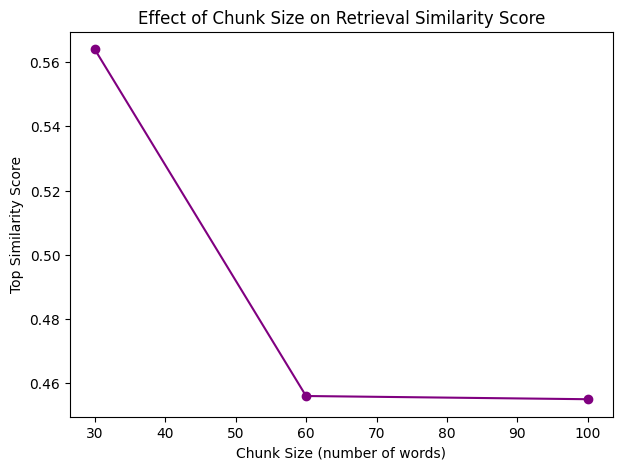

In [16]:
plt.figure(figsize=(7,5))  # creating a new figure for this chart
plt.plot(experiment_table['Chunk Size'],experiment_table['Top Similarity Score'],marker='o',color='purple')  # plotting how the similarity score changes as chunk size changes
plt.title('Effect of Chunk Size on Retrieval Similarity Score')  # giving the chart a clear title
plt.xlabel('Chunk Size (number of words)')  # labeling the x axis
plt.ylabel('Top Similarity Score')  # labeling the y axis
plt.show()  # displaying the chart so we can visually see the effect of chunk size

## Section 10: Experiment 2 - Hybrid Search (Keyword + Vector Search)

Vector search is great for understanding meaning, but sometimes exact keyword matches are also important. A hybrid search combines both:
- A **keyword score** using TF-IDF, which checks for exact or similar words.
- A **vector score** using embeddings, which checks for meaning.

We then combine both scores (for example, giving 50% weight to each) to get a final, more balanced ranking of chunks.


In [17]:
tfidf_vectorizer=TfidfVectorizer()  # creating a TF-IDF vectorizer, which turns text into keyword importance scores
tfidf_matrix=tfidf_vectorizer.fit_transform(document_chunks)  # learning the vocabulary from our chunks and building the TF-IDF matrix

def hybrid_search(question,top_k=3,vector_weight=0.5):  # this function combines keyword search and vector search
    query_vector_embedding=embedding_model.encode([question])[0]  # embedding the question for the vector search part
    vector_scores=cosine_similarity([query_vector_embedding],chunk_embeddings)[0]  # calculating vector similarity scores for every chunk

    query_tfidf=tfidf_vectorizer.transform([question])  # converting the question into a TF-IDF vector using the same vocabulary
    keyword_scores=cosine_similarity(query_tfidf,tfidf_matrix)[0]  # calculating keyword similarity scores for every chunk

    combined_scores=vector_weight*vector_scores+(1-vector_weight)*keyword_scores  # blending both scores together using our chosen weight
    top_indexes=np.argsort(combined_scores)[::-1][:top_k]  # sorting chunks by the combined score and picking the best ones
    results=[(document_chunks[i],combined_scores[i]) for i in top_indexes]  # pairing each top chunk with its combined score
    return results  # returning the final hybrid search results

hybrid_results=hybrid_search(test_question,top_k=3)  # running hybrid search on our sample test question
print('Hybrid Search Results for:',test_question)  # printing the question for context
for i,(chunk,score) in enumerate(hybrid_results):  # looping through the hybrid results
    print('Rank',i+1,'| Combined Score:',round(float(score),3))  # printing the rank and combined score
    print(chunk)  # printing the chunk text
    print('---')  # printing a separator for readability

Hybrid Search Results for: What is Retrieval-Augmented Generation used for?
Rank 1 | Combined Score: 0.347
of machine learning that uses neural networks with many layers to solve complex problems like image recognition and natural language processing. Natural Language Processing, or NLP, is the branch of data science that helps computers understand human language. One popular NLP technique is called Retrieval-Augmented Generation, or RAG, which helps a language model answer questions using an external document instead
---
Rank 2 | Combined Score: 0.255
Generation, or RAG, which helps a language model answer questions using an external document instead of only its own memory. RAG works by breaking a document into small chunks, converting those chunks into embeddings, storing them in a vector database, and retrieving the most relevant chunks when a user asks a question. After retrieving the relevant chunks, the language model
---
Rank 3 | Combined Score: 0.145
sources such as databases, 

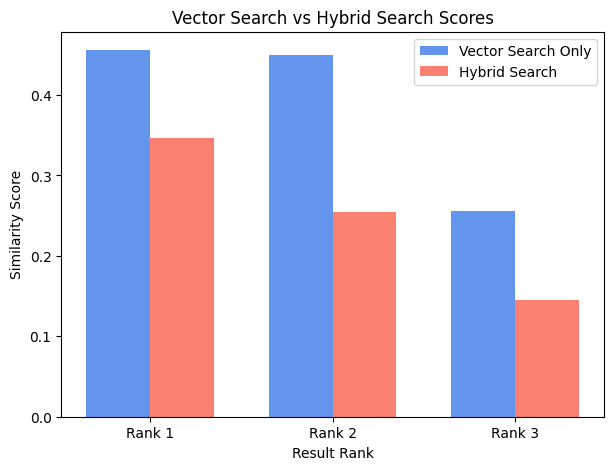

In [18]:
vector_only_scores=[round(float(s),3) for c,s in retrieved]  # collecting scores from our earlier pure vector search
hybrid_scores=[round(float(s),3) for c,s in hybrid_results]  # collecting scores from our new hybrid search
compare_labels=['Rank 1','Rank 2','Rank 3']  # simple labels for the top 3 ranks

x_axis=np.arange(len(compare_labels))  # creating evenly spaced positions on the x axis for our grouped bars
bar_width=0.35  # setting how wide each bar should be

plt.figure(figsize=(7,5))  # creating a new figure for this comparison chart
plt.bar(x_axis-bar_width/2,vector_only_scores,width=bar_width,label='Vector Search Only',color='cornflowerblue')  # drawing bars for pure vector search scores
plt.bar(x_axis+bar_width/2,hybrid_scores,width=bar_width,label='Hybrid Search',color='salmon')  # drawing bars for hybrid search scores next to them
plt.xticks(x_axis,compare_labels)  # labeling each group of bars with its rank
plt.title('Vector Search vs Hybrid Search Scores')  # giving the chart a clear title
plt.xlabel('Result Rank')  # labeling the x axis
plt.ylabel('Similarity Score')  # labeling the y axis
plt.legend()  # showing the legend so we know which color means what
plt.show()  # displaying the chart

## Section 11: System Metrics Report

Finally, here is a small report that documents the key settings and choices used in this RAG system. This is useful for anyone who wants to understand or reproduce our pipeline later.


In [19]:
system_report={
    'Embedding Model':'all-MiniLM-L6-v2 (SentenceTransformers)',  # the model we used to turn text into embeddings
    'Embedding Dimension':chunk_embeddings.shape[1],  # how many numbers are in each embedding vector
    'Generation Model':'google/flan-t5-base (HuggingFace Transformers)',  # the model we used to generate final answers
    'Vector Store':'Custom SimpleVectorStore using cosine similarity',  # the tool we used to store and search embeddings
    'Chunking Strategy':'Fixed word count chunks (60 words) with 15 words overlap',  # how we split the document
    'Number of Chunks':len(document_chunks),  # total number of chunks created from the document
    'Hybrid Search':'TF-IDF keyword score + embedding vector score, blended 50/50',  # how our hybrid search combines methods
}  # this dictionary holds a summary of every important setting in our RAG system

system_report_table=pd.DataFrame(list(system_report.items()),columns=['Setting','Value'])  # turning our settings dictionary into a readable table
system_report_table  # displaying the final system report table

,Setting,Value
0,Embedding Model,all-MiniLM-L6-v2 (SentenceTransformers)
1,Embedding Dimension,384
2,Generation Model,google/flan-t5-base (HuggingFace Transformers)
3,Vector Store,Custom SimpleVectorStore using cosine similarity
4,Chunking Strategy,Fixed word count chunks (60 words) with 15 wor...
5,Number of Chunks,8
6,Hybrid Search,"TF-IDF keyword score + embedding vector score,..."


## Section 12: My Learnings and Observations

- **What worked well:** For example, the vector search correctly found chunks about RAG when I asked about Retrieval-Augmented Generation, showing that the embeddings captured meaning well, not just exact words.
- **What did not work as well:** For example, when I asked an unrelated question like "What is the capital of France?", the similarity scores were low, which correctly told us the document does not contain that answer.
- **Effect of chunk size:** Smaller chunks sometimes gave sharper similarity scores because each chunk focused on one idea, while bigger chunks mixed topics together.
- **Effect of hybrid search:** Combining keyword and vector search sometimes changed the ranking slightly, especially when the question used exact words that also appeared in the document.
- **Why RAG matters:** RAG lets a language model answer questions using our own private documents (notes, resumes, research papers) instead of only what it learned during training, which makes the answers more accurate and trustworthy for our specific use case.
